IMPORTING ALL THE LIBRARIES

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns



LOADING AND PREPROCESSING 

In [ ]:
import pandas as pd
df= pd.read_csv(r"C:\Users\tavis\Downloads\archive (2)\zomato.csv")
df
df.head()
df.info()
df.describe()
df.columns
df.shape


<class 'pandas.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   url                          51717 non-null  str  
 1   address                      51717 non-null  str  
 2   name                         51717 non-null  str  
 3   online_order                 51717 non-null  str  
 4   book_table                   51717 non-null  str  
 5   rate                         43942 non-null  str  
 6   votes                        51717 non-null  int64
 7   phone                        50509 non-null  str  
 8   location                     51696 non-null  str  
 9   rest_type                    51490 non-null  str  
 10  dish_liked                   23639 non-null  str  
 11  cuisines                     51672 non-null  str  
 12  approx_cost(for two people)  51371 non-null  str  
 13  reviews_list                 51717 non-null  str  
 14  m

51717

DATA CLEANING

In [ ]:
df.isnull().sum()
df.dropna(inplace=True)
df.fillna(0,inplace=True)
df
df.duplicated().sum()
df[df.duplicated()]
df.drop_duplicates(inplace=True)
df.duplicated().sum()




np.int64(0)

In [ ]:

df['rate'] = df['rate'].astype(str)


df['rate'] = df['rate'].str.replace('/5', '').str.strip()

df['rate'] = df['rate'].replace(['NEW', '-', 'nan'], np.nan)


df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

df['rate']

df['approx_cost(for two people)'] = df['approx_cost(for two people)'].astype(str)

df['approx_cost(for two people)'] = df['approx_cost(for two people)'].str.replace(',', '').astype(float)
df['approx_cost(for two people)']

0         800.0
1         800.0
2         800.0
3         300.0
4         600.0
          ...  
51705    1200.0
51707    2000.0
51708    1200.0
51711     800.0
51715    2500.0
Name: approx_cost(for two people), Length: 23193, dtype: float64

VISUAL DATA ANALYSIS

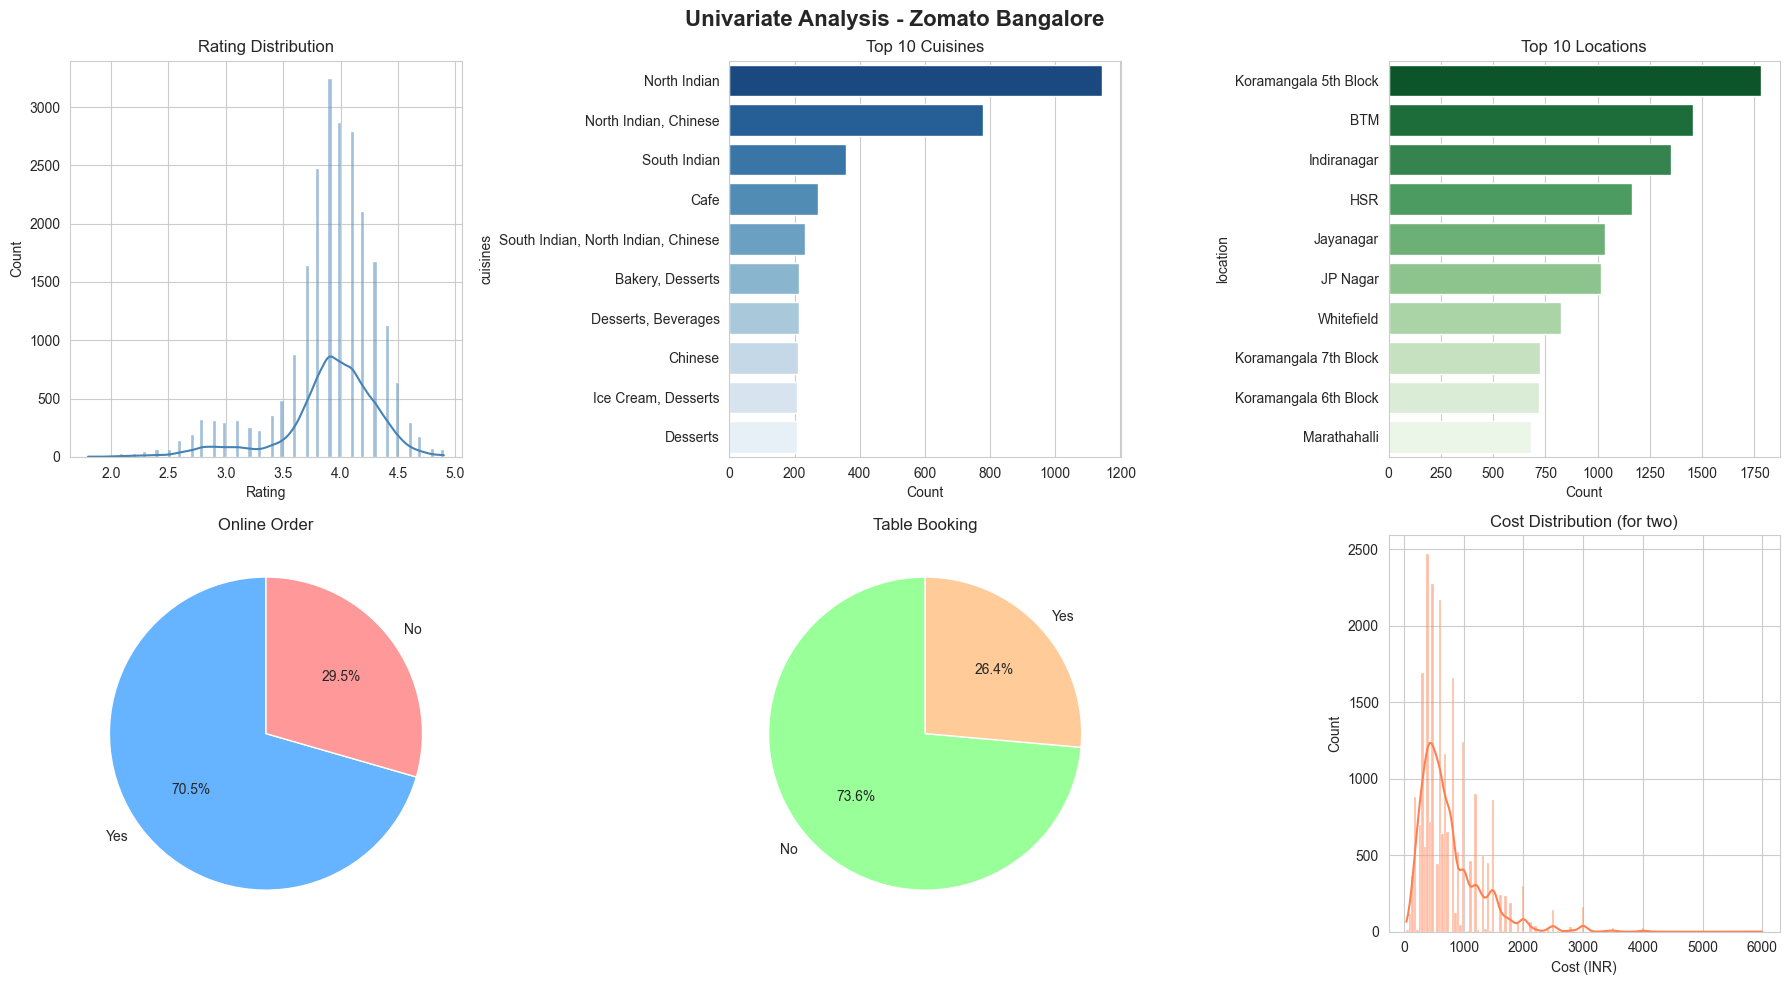

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Univariate Analysis - Zomato Bangalore', fontsize=16, fontweight='bold')

# 1. Rating distribution
sns.histplot(df['rate'].dropna(), kde=True, ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Rating Distribution')
axes[0,0].set_xlabel('Rating')

# 2. Top 10 cuisines
top_cuisines = df['cuisines'].value_counts().head(10)
sns.barplot(x=top_cuisines.values, y=top_cuisines.index, ax=axes[0,1],
            hue=top_cuisines.index, palette='Blues_r', legend=False)
axes[0,1].set_title('Top 10 Cuisines')
axes[0,1].set_xlabel('Count')

# 3. Top 10 locations
top_locations = df['location'].value_counts().head(10)
sns.barplot(x=top_locations.values, y=top_locations.index, ax=axes[0,2],
            hue=top_locations.index, palette='Greens_r', legend=False)
axes[0,2].set_title('Top 10 Locations')
axes[0,2].set_xlabel('Count')

# 4. Online order split
online_counts = df['online_order'].value_counts()
axes[1,0].pie(online_counts, labels=online_counts.index, autopct='%1.1f%%',
              colors=['#66b3ff','#ff9999'], startangle=90)
axes[1,0].set_title('Online Order')

# 5. Table booking split
book_counts = df['book_table'].value_counts()
axes[1,1].pie(book_counts, labels=book_counts.index, autopct='%1.1f%%',
              colors=['#99ff99','#ffcc99'], startangle=90)
axes[1,1].set_title('Table Booking')

# 6. Cost distribution
sns.histplot(df['approx_cost(for two people)'].dropna(), kde=True, ax=axes[1,2], color='coral')
axes[1,2].set_title('Cost Distribution (for two)')
axes[1,2].set_xlabel('Cost (INR)')

plt.tight_layout()
plt.savefig('univariate_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

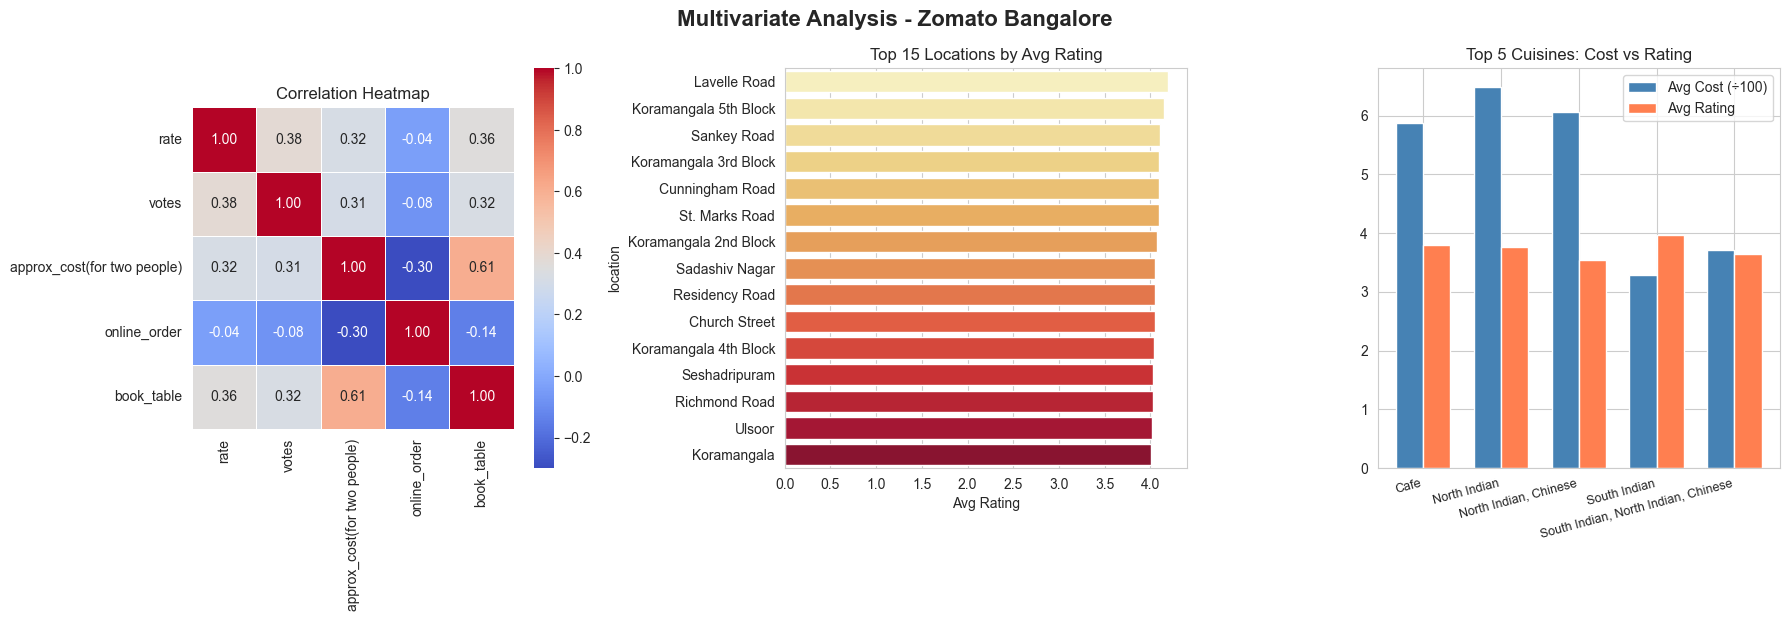

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Multivariate Analysis - Zomato Bangalore', fontsize=16, fontweight='bold')

# 1. Correlation heatmap
df_encoded = df.copy()
df_encoded['online_order'] = df_encoded['online_order'].map({'Yes': 1, 'No': 0})
df_encoded['book_table'] = df_encoded['book_table'].map({'Yes': 1, 'No': 0})

corr_cols = ['rate', 'votes', 'approx_cost(for two people)', 'online_order', 'book_table']
corr_matrix = df_encoded[corr_cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[0], linewidths=0.5, square=True)
axes[0].set_title('Correlation Heatmap')

# 2. Location vs avg rating (top 15)
location_rating = df.groupby('location')['rate'].mean().sort_values(ascending=False).head(15)
sns.barplot(x=location_rating.values, y=location_rating.index, ax=axes[1],
            hue=location_rating.index, palette='YlOrRd', legend=False)
axes[1].set_title('Top 15 Locations by Avg Rating')
axes[1].set_xlabel('Avg Rating')

# 3. Top 5 cuisines - avg cost vs avg rating side by side
top5_cuisines = df['cuisines'].value_counts().head(5).index
cuisine_grouped = df[df['cuisines'].isin(top5_cuisines)].groupby('cuisines').agg(
    avg_cost=('approx_cost(for two people)', 'mean'),
    avg_rating=('rate', 'mean')
).reset_index()

x = range(len(cuisine_grouped))
width = 0.35
axes[2].bar([i - width/2 for i in x], cuisine_grouped['avg_cost'] / 100,
            width, label='Avg Cost (÷100)', color='steelblue')
axes[2].bar([i + width/2 for i in x], cuisine_grouped['avg_rating'],
            width, label='Avg Rating', color='coral')
axes[2].set_xticks(list(x))
axes[2].set_xticklabels(cuisine_grouped['cuisines'], rotation=15, ha='right', fontsize=9)
axes[2].set_title('Top 5 Cuisines: Cost vs Rating')
axes[2].legend()

plt.tight_layout()
plt.savefig('multivariate_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

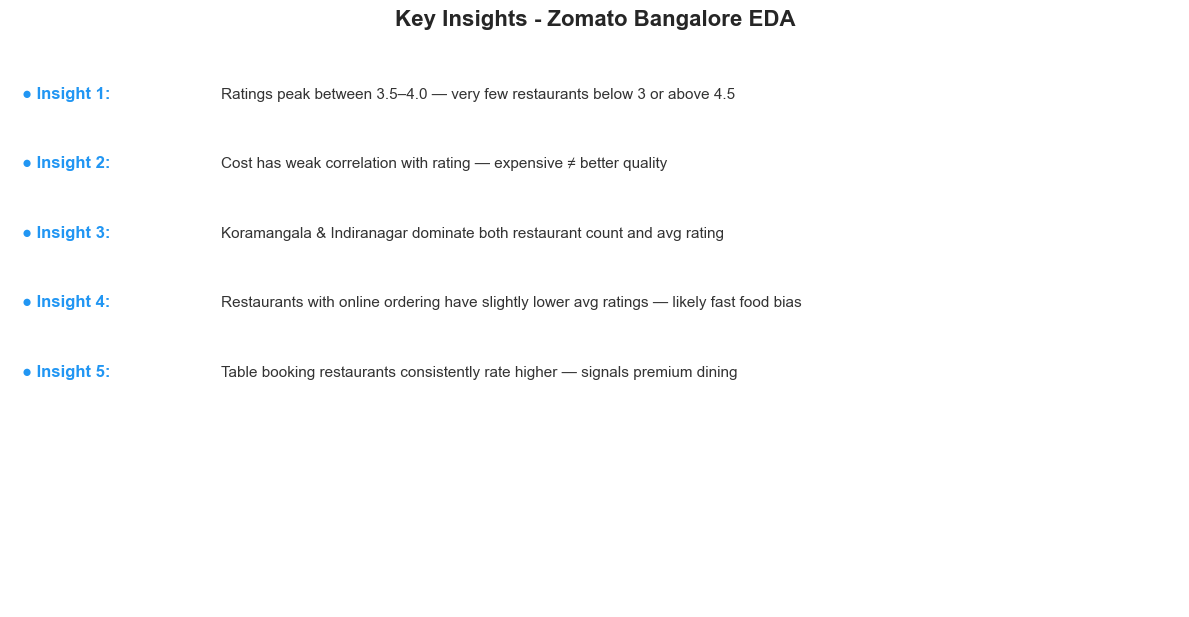


✅ EDA Complete!
Dataset shape after cleaning: (23193, 17)
Avg rating across all restaurants: 3.90
Avg cost for two: ₹756
% restaurants with online ordering: 70.5%


In [46]:
insights = {
    "Insight 1": "Ratings peak between 3.5–4.0 — very few restaurants below 3 or above 4.5",
    "Insight 2": "Cost has weak correlation with rating — expensive ≠ better quality",
    "Insight 3": "Koramangala & Indiranagar dominate both restaurant count and avg rating",
    "Insight 4": "Restaurants with online ordering have slightly lower avg ratings — likely fast food bias",
    "Insight 5": "Table booking restaurants consistently rate higher — signals premium dining",
    
}

fig, ax = plt.subplots(figsize=(12, 6))
ax.axis('off')

y_pos = 0.95
for title, text in insights.items():
    color = '#2196F3' if 'Insight' in title else '#E91E63'
    ax.text(0.01, y_pos, f'● {title}:', fontsize=12, fontweight='bold',
            color=color, transform=ax.transAxes)
    ax.text(0.18, y_pos, text, fontsize=11, color='#333333',
            transform=ax.transAxes, wrap=True)
    y_pos -= 0.13

fig.suptitle('Key Insights - Zomato Bangalore EDA', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('key_insights.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ EDA Complete!")
print(f"Dataset shape after cleaning: {df.shape}")
print(f"Avg rating across all restaurants: {df['rate'].mean():.2f}")
print(f"Avg cost for two: ₹{df['approx_cost(for two people)'].mean():.0f}")
print(f"% restaurants with online ordering: {(df['online_order']=='Yes').mean()*100:.1f}%")